# Working with NumPy Array Images

In [1]:
import itk
import numpy as np
import imageio
import matplotlib.pyplot as plt

The images are plotted with matplotlib.

In [2]:
def compare(image1, image2, titles):
    """Plot two images side by side."""
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    for ax, image, title in zip(axes, (image1, image2), titles):
        ax.imshow(image, cmap="gray")
        ax.set_title(title)
        ax.axis("off")
    plt.show()


def checkerboard(image1, image2, pattern):
    """Plot a checkerboard that alternates blocks of two images."""
    checkerboard_image = itk.checker_board_image_filter(
        image1, image2, checker_pattern=pattern
    )
    plt.imshow(checkerboard_image, cmap="gray")
    plt.axis("off")
    plt.show()

Images as NumPy arrays can be registered.

Convert them to floating point arrays, then to ITK images for registration.

In [3]:
fixed = imageio.imread("data/CT_2D_head_fixed.mha")
fixed = np.asarray(fixed).astype(np.float32)
type(fixed)

Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.


numpy.ndarray

In [4]:
moving = imageio.imread("data/CT_2D_head_moving.mha")
moving = np.asarray(moving).astype(np.float32)
type(moving)

Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.


numpy.ndarray

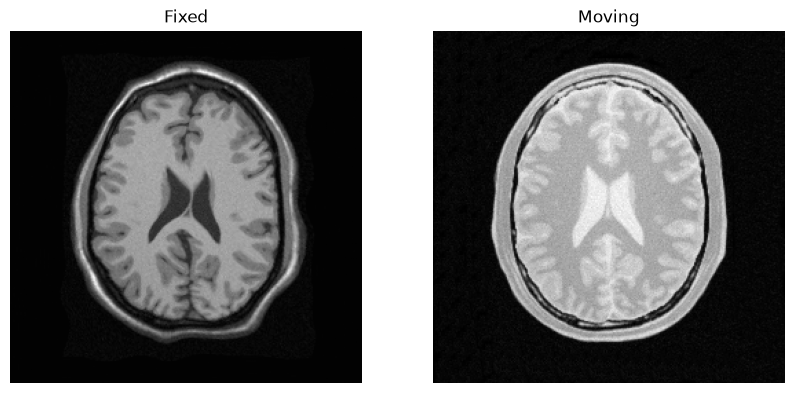

In [5]:
compare(fixed, moving, titles=("Fixed", "Moving"))

Before registration, the moving image is not aligned with the fixed image.

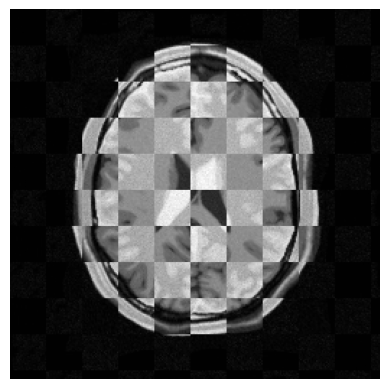

In [6]:
checkerboard(fixed, moving, pattern=10)

In [7]:
# Register!
registered, parameters = itk.elastix_registration_method(
    itk.image_from_array(fixed), itk.image_from_array(moving))
type(registered)

itk.itkImagePython.itkImageF2

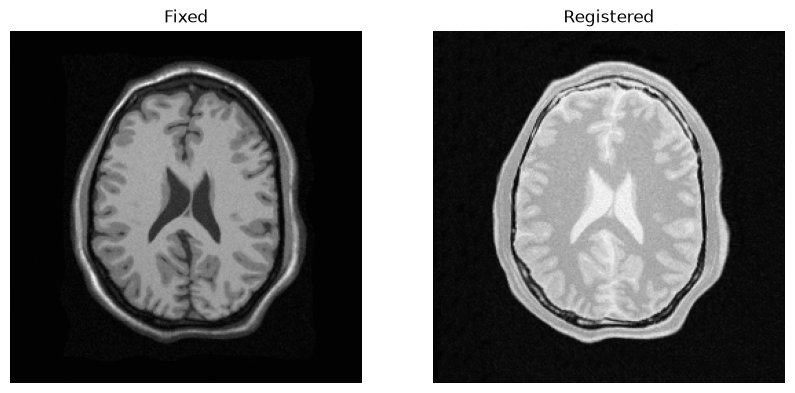

In [8]:
compare(fixed, registered, titles=("Fixed", "Registered"))

The registered moving image is aligned with the fixed image

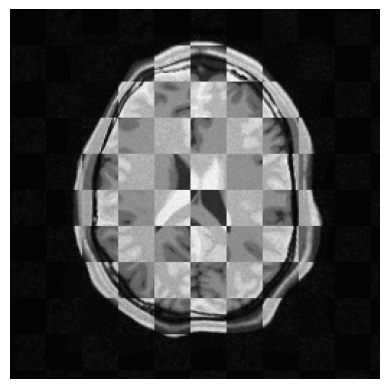

In [9]:
checkerboard(fixed, registered, pattern=10)